In [1]:
# ============================================================
# 01_exploration.ipynb
# Exploration des données de stock SAGE
# Changer BASE_NAME pour analyser une autre base 
# ============================================================

# ── Cellule 1 : Configuration ────────────────────────────────
BASE_NAME = 'BIJOU'   # ← changer ici pour STE_NGDM ou autre base pour l'analyse 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine, text
import pyodbc
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
sns.set_palette('tab10')

print(f"✅ Configuration chargée — Base cible : {BASE_NAME}")

✅ Configuration chargée — Base cible : BIJOU


In [2]:
from sqlalchemy import create_engine, text

SERVER   = r'SALMAIKSOD\SAGE100'
DATABASE = 'Test'
USERNAME = 'sa'
PASSWORD = '123456'

# SQLAlchemy avec SQL Auth
conn_str = (
    f"mssql+pyodbc://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}"
    f"?driver=ODBC+Driver+17+for+SQL+Server"
    f"&TrustServerCertificate=yes"
)

engine = create_engine(conn_str, fast_executemany=True)

# Test
with engine.connect() as conn:
    r = conn.execute(text("SELECT DB_NAME() AS db")).fetchone()
    print(f"✅ Connexion SQLAlchemy OK — Base active : {r.db}")

✅ Connexion SQLAlchemy OK — Base active : Test


In [3]:
import os
os.makedirs('../outputs', exist_ok=True)

query = text("""
SELECT 
    BaseName, DateJour, AR_Ref, AR_Design,
    FA_CodeFamille, FA_Intitule,
    CL_No1, CL_Intitule1,
    DE_No, DE_Intitule,
    TotalEntree, TotalSortie,
    ValeurEntree, ValeurSortie,
    StockFinal, ValeurFinale
FROM Test.stock.VW_StockJoursAvecMvt
WHERE BaseName = :base
ORDER BY AR_Ref, DE_No, DateJour
""")

with engine.connect() as conn:
    df_raw = pd.read_sql(query, conn, params={'base': BASE_NAME})

# Types
df_raw['DateJour']     = pd.to_datetime(df_raw['DateJour'])
df_raw['DE_No']        = pd.to_numeric(df_raw['DE_No'],        errors='coerce').fillna(0).astype(int)
df_raw['TotalEntree']  = pd.to_numeric(df_raw['TotalEntree'],  errors='coerce').fillna(0)
df_raw['TotalSortie']  = pd.to_numeric(df_raw['TotalSortie'],  errors='coerce').fillna(0)
df_raw['ValeurEntree'] = pd.to_numeric(df_raw['ValeurEntree'], errors='coerce').fillna(0)
df_raw['ValeurSortie'] = pd.to_numeric(df_raw['ValeurSortie'], errors='coerce').fillna(0)
df_raw['StockFinal']   = pd.to_numeric(df_raw['StockFinal'],   errors='coerce').fillna(0)
df_raw['ValeurFinale'] = pd.to_numeric(df_raw['ValeurFinale'], errors='coerce').fillna(0)

print(f"✅ Données chargées")
print(f"   Lignes           : {len(df_raw):,}")
print(f"   Articles uniques : {df_raw['AR_Ref'].nunique():,}")
print(f"   Dépôts uniques   : {df_raw['DE_No'].nunique():,}")
print(f"   Période          : {df_raw['DateJour'].min().date()} → {df_raw['DateJour'].max().date()}")
print(f"   Jours couverts   : {df_raw['DateJour'].nunique():,}")
df_raw.head(3)

✅ Données chargées
   Lignes           : 88
   Articles uniques : 45
   Dépôts uniques   : 2
   Période          : 2025-01-02 → 2025-03-18
   Jours couverts   : 18


,BaseName,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,DE_No,DE_Intitule,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,StockFinal,ValeurFinale
0,BIJOU,2025-01-02,BAAR01,Bague Argent,BIJOUXARG,Bijouterie Argent,2,Bijoux,1,Bijou SA,5.0,0.0,762.6,0.00,5.0,762.60
1,BIJOU,2025-01-03,BAAR01,Bague Argent,BIJOUXARG,Bijouterie Argent,2,Bijoux,1,Bijou SA,10.0,4.0,1860.0,524.52,11.0,2098.08
2,BIJOU,2025-01-17,BAAR01,Bague Argent,BIJOUXARG,Bijouterie Argent,2,Bijoux,1,Bijou SA,5.0,0.0,818.4,0.00,16.0,2916.48


In [4]:
print("=" * 60)
print(f"RAPPORT QUALITÉ — {BASE_NAME}")
print("=" * 60)

# Valeurs manquantes
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
df_missing = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage %': missing_pct
}).query('Manquants > 0')

if df_missing.empty:
    print("\n✅ Aucune valeur manquante")
else:
    print("\n⚠️  Valeurs manquantes :")
    print(df_missing.to_string())

# Stats des colonnes clés
print(f"\n📊 Statistiques clés :")
cols_stats = ['TotalEntree', 'TotalSortie', 'ValeurEntree', 'ValeurSortie', 'StockFinal', 'ValeurFinale']
print(df_raw[cols_stats].describe().round(2).to_string())

# Lignes avec sorties nulles
pct_zero_sortie = (df_raw['TotalSortie'] == 0).mean() * 100
print(f"\n   Jours sans sortie : {pct_zero_sortie:.1f}%")
print(f"   Jours avec sortie : {100 - pct_zero_sortie:.1f}%")

RAPPORT QUALITÉ — BIJOU

✅ Aucune valeur manquante

📊 Statistiques clés :
       TotalEntree  TotalSortie  ValeurEntree  ValeurSortie  StockFinal  ValeurFinale
count        88.00        88.00         88.00         88.00       88.00         88.00
mean         29.30         2.70       9272.74        698.65       52.63      11018.53
std          56.15         6.11      57368.42       3434.14       67.43      57326.68
min           0.00         0.00          0.00          0.00        0.00      -7345.30
25%           0.00         0.00          0.00          0.00       10.00        564.38
50%           4.50         0.00        516.27          0.00       34.50       1736.91
75%          40.00         2.00       2523.00         78.88       66.25       6916.25
max         400.00        48.00     538000.00      26500.00      352.00     538000.00

   Jours sans sortie : 52.3%
   Jours avec sortie : 47.7%


Articles prévisibles  (>= 60j) : 0
Articles non prévisibles (< 60j) : 45
Total                               : 45


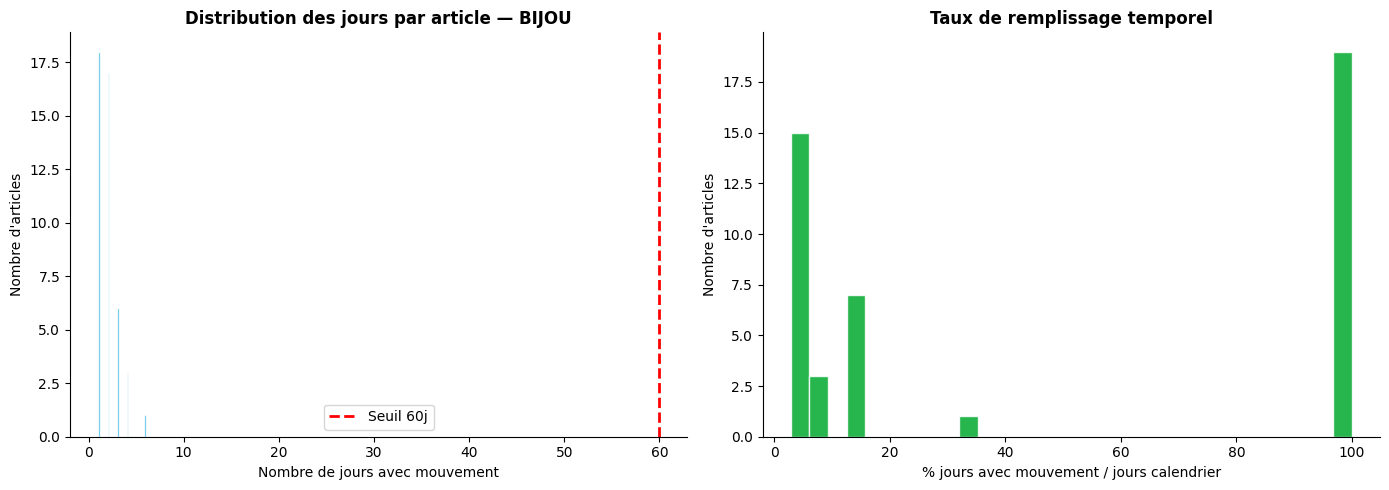

✅ Graphique sauvegardé


In [5]:
hist = (
    df_raw.groupby('AR_Ref')['DateJour']
    .agg(nb_jours='count', date_min='min', date_max='max')
    .assign(
        jours_cal=lambda x: (x['date_max'] - x['date_min']).dt.days + 1,
        taux_remplissage=lambda x: (x['nb_jours'] / x['jours_cal'] * 100).round(1)
    )
    .sort_values('nb_jours', ascending=False)
    .reset_index()
)

seuil = 60
n_ok = (hist['nb_jours'] >= seuil).sum()
n_ko = (hist['nb_jours'] <  seuil).sum()

print(f"Articles prévisibles  (>= {seuil}j) : {n_ok}")
print(f"Articles non prévisibles (< {seuil}j) : {n_ko}")
print(f"Total                               : {len(hist)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hist['nb_jours'], bins=30, color='#12a6e0', edgecolor='white', alpha=0.85)
axes[0].axvline(seuil, color='red', linestyle='--', linewidth=2, label=f'Seuil {seuil}j')
axes[0].set_title(f'Distribution des jours par article — {BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Nombre de jours avec mouvement")
axes[0].set_ylabel("Nombre d'articles")
axes[0].legend()

axes[1].hist(hist['taux_remplissage'], bins=30, color='#01a82e', edgecolor='white', alpha=0.85)
axes[1].set_title('Taux de remplissage temporel', fontweight='bold')
axes[1].set_xlabel("% jours avec mouvement / jours calendrier")
axes[1].set_ylabel("Nombre d'articles")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_01_historique.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé")

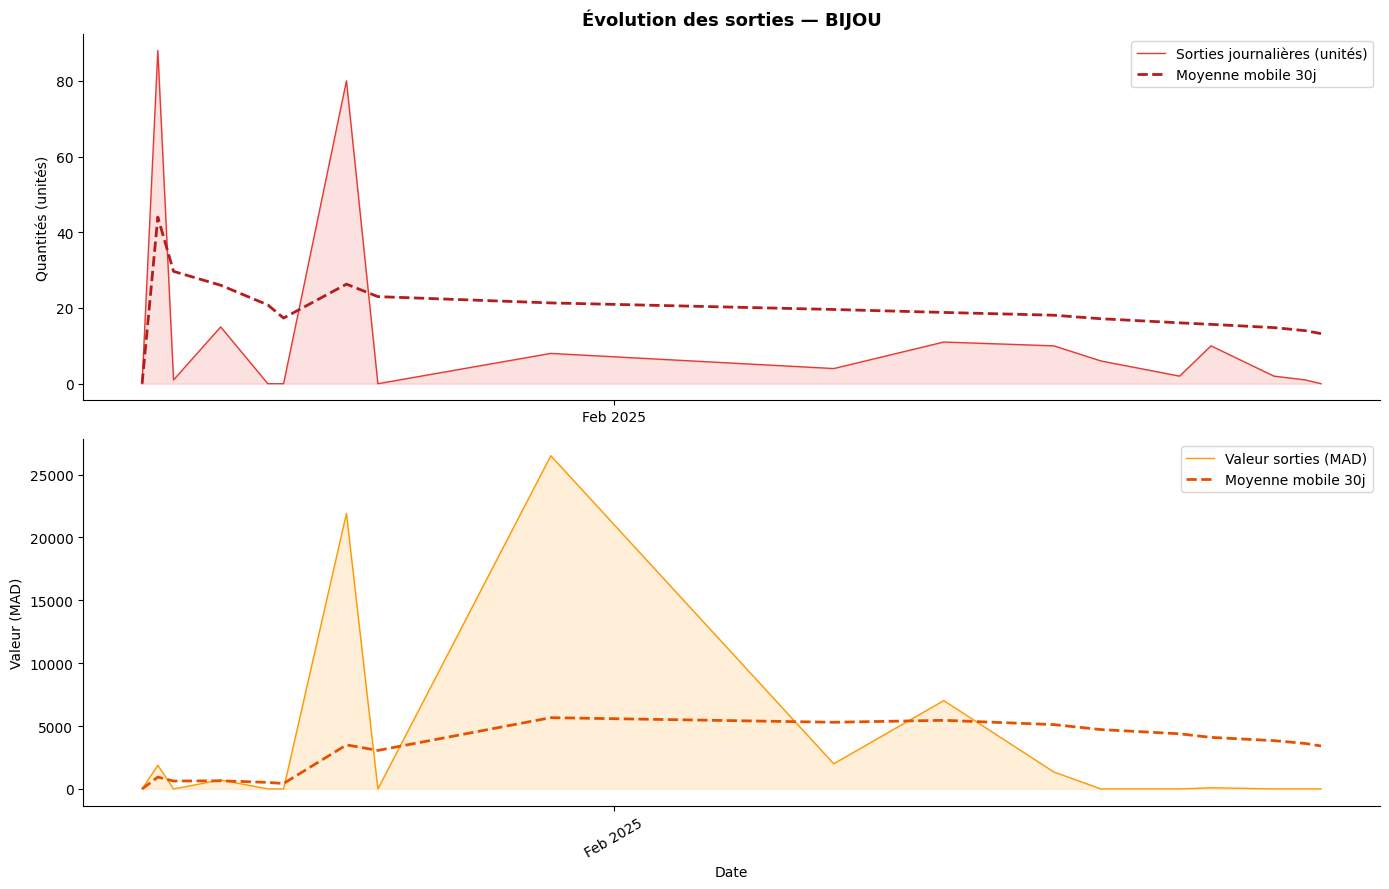

In [6]:
sorties_jour = (
    df_raw.groupby('DateJour')[['TotalSortie', 'ValeurSortie']]
    .sum()
    .reset_index()
)
sorties_jour['ma30_qte']    = sorties_jour['TotalSortie'].rolling(30, min_periods=1).mean()
sorties_jour['ma30_valeur'] = sorties_jour['ValeurSortie'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Quantités
axes[0].fill_between(sorties_jour['DateJour'], sorties_jour['TotalSortie'],
                     alpha=0.15, color='#e53935')
axes[0].plot(sorties_jour['DateJour'], sorties_jour['TotalSortie'],
             color='#e53935', linewidth=1, label='Sorties journalières (unités)')
axes[0].plot(sorties_jour['DateJour'], sorties_jour['ma30_qte'],
             color='#b71c1c', linewidth=2, linestyle='--', label='Moyenne mobile 30j')
axes[0].set_title(f'Évolution des sorties — {BASE_NAME}', fontweight='bold', fontsize=13)
axes[0].set_ylabel("Quantités (unités)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Valeurs MAD
axes[1].fill_between(sorties_jour['DateJour'], sorties_jour['ValeurSortie'],
                     alpha=0.15, color='#ff9800')
axes[1].plot(sorties_jour['DateJour'], sorties_jour['ValeurSortie'],
             color='#ff9800', linewidth=1, label='Valeur sorties (MAD)')
axes[1].plot(sorties_jour['DateJour'], sorties_jour['ma30_valeur'],
             color='#e65100', linewidth=2, linestyle='--', label='Moyenne mobile 30j')
axes[1].set_ylabel("Valeur (MAD)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_02_sorties_globales.png', dpi=150, bbox_inches='tight')
plt.show()

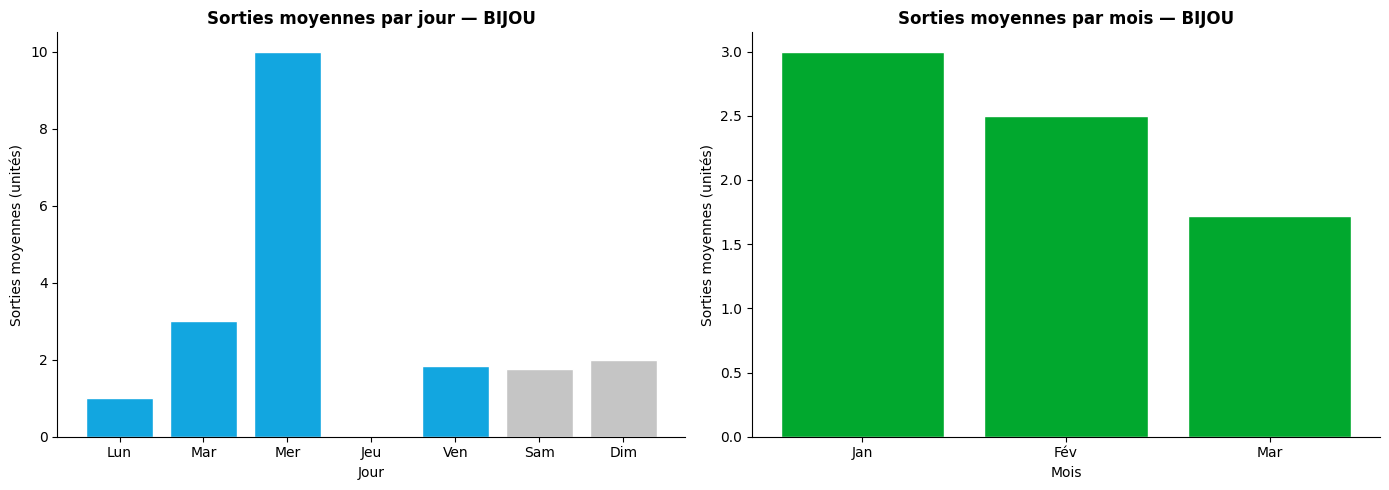

In [7]:
df_raw['jour_semaine']  = df_raw['DateJour'].dt.dayofweek
df_raw['nom_jour']      = df_raw['DateJour'].dt.day_name()
df_raw['mois']          = df_raw['DateJour'].dt.month

ordre_jours  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
labels_fr    = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
colors_week  = ['#12a6e0']*5 + ['#c5c5c5']*2

sorties_sem = (
    df_raw.groupby('nom_jour')['TotalSortie']
    .mean()
    .reindex(ordre_jours)
)

noms_mois_fr = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
sorties_mois = df_raw.groupby('mois')['TotalSortie'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels_fr, sorties_sem.values, color=colors_week, edgecolor='white')
axes[0].set_title(f'Sorties moyennes par jour — {BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Jour"); axes[0].set_ylabel("Sorties moyennes (unités)")

axes[1].bar(
    [noms_mois_fr[m-1] for m in sorties_mois.index],
    sorties_mois.values,
    color='#01a82e', edgecolor='white'
)
axes[1].set_title(f'Sorties moyennes par mois — {BASE_NAME}', fontweight='bold')
axes[1].set_xlabel("Mois"); axes[1].set_ylabel("Sorties moyennes (unités)")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_03_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

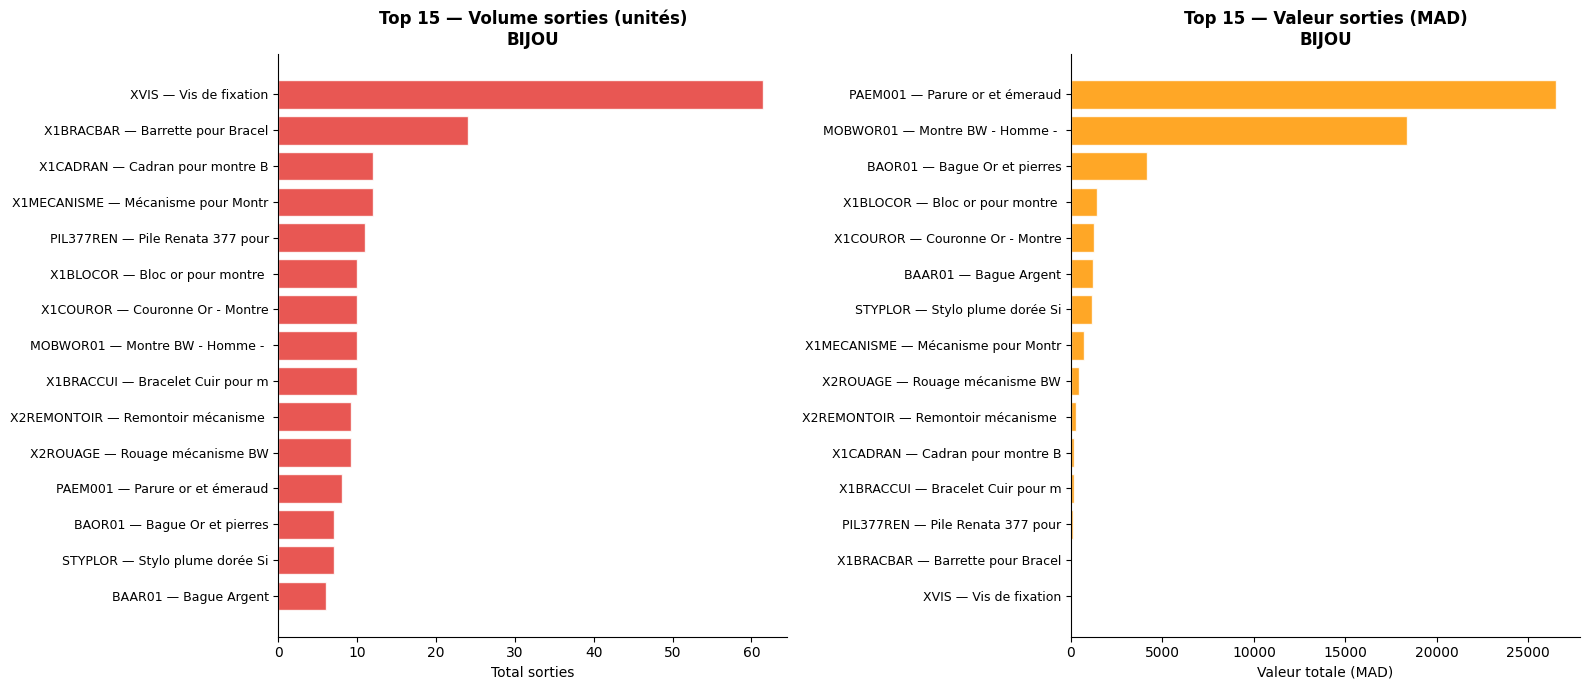

     AR_Ref                        AR_Design  total_sortie_qte  total_sortie_val  nb_jours
       XVIS                  Vis de fixation             61.50              5.55         3
  X1BRACBAR Barrette pour Bracelet montre BW             24.00             21.60         2
   X1CADRAN            Cadran pour montre BW             12.00            141.60         2
X1MECANISME         Mécanisme pour Montre BW             12.00            734.64         3
  PIL377REN     Pile Renata 377 pour montres             11.00            113.75         4
   X1BLOCOR           Bloc or pour montre BW             10.00           1450.00         2
   X1COUROR  Couronne Or - Montre BW Bloc Or             10.00           1233.00         2
   MOBWOR01      Montre BW - Homme - Bloc Or             10.00          18345.30         2
  X1BRACCUI     Bracelet Cuir pour montre BW             10.00            140.00         2
X2REMONTOIR           Remontoir mécanisme BW              9.25            261.78         2

In [8]:
top_art = (
    df_raw.groupby(['AR_Ref', 'AR_Design'])
    .agg(
        total_sortie_qte=('TotalSortie',   'sum'),
        total_sortie_val=('ValeurSortie',  'sum'),
        nb_jours=        ('DateJour',      'count')
    )
    .sort_values('total_sortie_qte', ascending=False)
    .head(15)
    .reset_index()
)
top_art['label'] = top_art['AR_Ref'] + ' — ' + top_art['AR_Design'].str[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Par quantité
axes[0].barh(range(len(top_art)), top_art['total_sortie_qte'],
             color='#e53935', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(top_art)))
axes[0].set_yticklabels(top_art['label'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title(f'Top 15 — Volume sorties (unités)\n{BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Total sorties")

# Par valeur MAD
top_val = top_art.sort_values('total_sortie_val', ascending=False)
axes[1].barh(range(len(top_val)), top_val['total_sortie_val'],
             color='#ff9800', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top_val)))
axes[1].set_yticklabels(top_val['label'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title(f'Top 15 — Valeur sorties (MAD)\n{BASE_NAME}', fontweight='bold')
axes[1].set_xlabel("Valeur totale (MAD)")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_04_top_articles.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_art[['AR_Ref', 'AR_Design', 'total_sortie_qte', 'total_sortie_val', 'nb_jours']].to_string(index=False))

Articles avec stock minimum <= 0 : 1
Articles ayant été à zéro (>= 1j): 1
Articles à risque élevé (>= 5j)  : 0


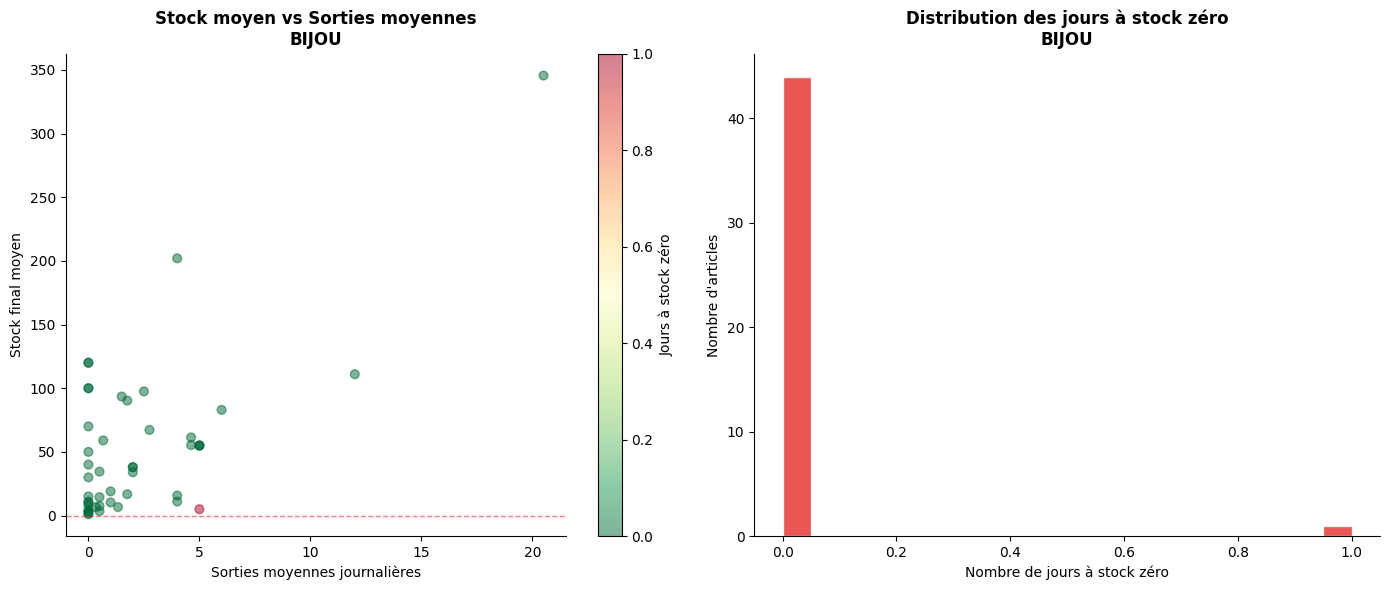

In [9]:
stock_analyse = (
    df_raw.groupby(['AR_Ref', 'AR_Design'])
    .agg(
        stock_moyen=     ('StockFinal',   'mean'),
        stock_min=       ('StockFinal',   'min'),
        stock_max=       ('StockFinal',   'max'),
        sorties_moy=     ('TotalSortie',  'mean'),
        nb_jours_zero=   ('StockFinal',   lambda x: (x <= 0).sum()),
        valeur_moy=      ('ValeurFinale', 'mean')
    )
    .reset_index()
    .sort_values('stock_moyen')
)

print(f"Articles avec stock minimum <= 0 : {(stock_analyse['stock_min'] <= 0).sum()}")
print(f"Articles ayant été à zéro (>= 1j): {(stock_analyse['nb_jours_zero'] > 0).sum()}")
print(f"Articles à risque élevé (>= 5j)  : {(stock_analyse['nb_jours_zero'] >= 5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(
    stock_analyse['sorties_moy'],
    stock_analyse['stock_moyen'],
    c=stock_analyse['nb_jours_zero'],
    cmap='RdYlGn_r', alpha=0.5, s=40
)
plt.colorbar(sc, ax=axes[0], label='Jours à stock zéro')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title(f'Stock moyen vs Sorties moyennes\n{BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Sorties moyennes journalières")
axes[0].set_ylabel("Stock final moyen")

axes[1].hist(stock_analyse['nb_jours_zero'], bins=20,
             color='#e53935', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Distribution des jours à stock zéro\n{BASE_NAME}', fontweight='bold')
axes[1].set_xlabel("Nombre de jours à stock zéro")
axes[1].set_ylabel("Nombre d'articles")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_05_risques_rupture.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
articles_previsibles = hist[hist['nb_jours'] >= 60][['AR_Ref', 'nb_jours']]
articles_risque      = stock_analyse[stock_analyse['nb_jours_zero'] >= 5]

print("=" * 60)
print(f"RÉSUMÉ EXPLORATION — {BASE_NAME}")
print("=" * 60)
print(f"\n📦 Articles total              : {df_raw['AR_Ref'].nunique()}")
print(f"✅ Prévisibles (>= 60j mvt)    : {len(articles_previsibles)}")
print(f"❌ Non prévisibles (<  60j)    : {df_raw['AR_Ref'].nunique() - len(articles_previsibles)}")
print(f"🔴 Articles à risque rupture   : {len(articles_risque)}")
print(f"🏪 Dépôts                      : {df_raw['DE_No'].nunique()}")
print(f"\n📅 Période                     : {df_raw['DateJour'].min().date()} → {df_raw['DateJour'].max().date()}")
print(f"📈 Jours avec mouvement        : {df_raw['DateJour'].nunique()}")
print(f"💰 Valeur totale sorties (MAD) : {df_raw['ValeurSortie'].sum():,.2f}")

# Sauvegarder pour notebook 02
df_raw.to_parquet(f'../outputs/{BASE_NAME}_raw.parquet', index=False)
articles_previsibles.to_csv(f'../outputs/{BASE_NAME}_articles_previsibles.csv', index=False)

print(f"\n✅ Données sauvegardées dans outputs/")
print(f"   → {BASE_NAME}_raw.parquet")
print(f"   → {BASE_NAME}_articles_previsibles.csv")
print(f"\n➡️  Passer au notebook 02_preprocessing.ipynb")

RÉSUMÉ EXPLORATION — BIJOU

📦 Articles total              : 45
✅ Prévisibles (>= 60j mvt)    : 0
❌ Non prévisibles (<  60j)    : 45
🔴 Articles à risque rupture   : 0
🏪 Dépôts                      : 2

📅 Période                     : 2025-01-02 → 2025-03-18
📈 Jours avec mouvement        : 18
💰 Valeur totale sorties (MAD) : 61,481.62

✅ Données sauvegardées dans outputs/
   → BIJOU_raw.parquet
   → BIJOU_articles_previsibles.csv

➡️  Passer au notebook 02_preprocessing.ipynb
